# Classification fine-tuning using Helical

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/helicalAI/helical/blob/main/examples/notebooks/Cell-Type-Classification-Fine-Tuning.ipynb)

## Cell type classification task

In [1]:
!pip install helical

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of gtfparse to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of gtfparse to determine which version is compatible with other requirements. This co

In [3]:
!pip install --upgrade torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 104.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 96.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 79.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 20.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 40.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99

Need to restart!

In [1]:
import torch
import torchvision
import transformers
print(torch.__version__, torchvision.__version__)


2.5.1+cu121 0.20.1+cu121


In [2]:
from helical.utils import get_anndata_from_hf_dataset
from helical.models.geneformer import GeneformerConfig, GeneformerFineTuningModel
from helical.models.scgpt import scGPTConfig, scGPTFineTuningModel
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import logging, warnings
import umap
import pandas as pd
import seaborn as sns

logging.getLogger().setLevel(logging.ERROR)

warnings.filterwarnings("ignore")

INFO:numexpr.utils:NumExpr defaulting to 8 threads.
INFO:datasets:PyTorch version 2.5.1+cu121 available.
INFO:datasets:Polars version 1.25.2 available.
INFO:datasets:Duckdb version 1.3.2 available.
INFO:datasets:TensorFlow version 2.19.0 available.
INFO:datasets:JAX version 0.5.3 available.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### Install datasets

In [4]:
from datasets import load_dataset
ds = load_dataset("helical-ai/yolksac_human",trust_remote_code=True, download_mode="reuse_cache_if_exists")

README.md: 0.00B [00:00, ?B/s]

yolksac_human.py: 0.00B [00:00, ?B/s]

./data/17_04_24_YolkSacRaw_F158_WE_annot(…):   0%|          | 0.00/553M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [14]:
ds

DatasetDict({
    train: Dataset({
        features: ['raw_counts', 'rows', 'size', 'LVL1', 'LVL2', 'LVL3'],
        num_rows: 25344
    })
    test: Dataset({
        features: ['raw_counts', 'rows', 'size', 'LVL1', 'LVL2', 'LVL3'],
        num_rows: 6336
    })
})

In [5]:
train_dataset = get_anndata_from_hf_dataset(ds["train"])
test_dataset = get_anndata_from_hf_dataset(ds["test"])

## Prepare training labels

- For this classification task we want to predict cell type classes
- So we save the cell types as a list

In [6]:
cell_types_train = list(np.array(train_dataset.obs["LVL1"].tolist()))
cell_types_test = list(np.array(test_dataset.obs["LVL1"].tolist()))

- We convert these string labels into unique integer classes for training

In [7]:
label_set = set(cell_types_train) | set(cell_types_test)
class_id_dict = dict(zip(label_set, [i for i in range(len(label_set))]))
id_class_dict = {v: k for k, v in class_id_dict.items()}

for i in range(len(cell_types_train)):
    cell_types_train[i] = class_id_dict[cell_types_train[i]]

for i in range(len(cell_types_test)):
    cell_types_test[i] = class_id_dict[cell_types_test[i]]



## Geneformer Fine-Tuning

- Choose the desired configs
- Define the Geneformer Fine-Tuning Model from the Helical package which appends a fine-tuning head automatically from the list of available heads
- Define the task type, which in this case is classification
- Defined the output size, which is the number of unique labels for classification

In [8]:
geneformer_config = GeneformerConfig(device=device, batch_size=10, model_name="gf-6L-10M-i2048")
geneformer_fine_tune = GeneformerFineTuningModel(geneformer_config=geneformer_config, fine_tuning_head="classification", output_size=len(label_set))

gene_median_dictionary.pkl: 100%|██████████| 941k/941k [00:01<00:00, 782kB/s]
token_dictionary.pkl: 100%|██████████| 788k/788k [00:00<00:00, 295MB/s]
ensembl_mapping_dict.pkl: 100%|██████████| 3.96M/3.96M [00:00<00:00, 8.21MB/s]
config.json: 100%|██████████| 565/565 [00:00<00:00, 1.53MB/s]
training_args.bin: 100%|██████████| 2.61k/2.61k [00:00<00:00, 11.0MB/s]
pytorch_model.bin: 100%|██████████| 41.2M/41.2M [00:02<00:00, 14.1MB/s]


Process the data so it is in the correct form for Geneformer

In [9]:
geneformer_train_dataset = geneformer_fine_tune.process_data(train_dataset)
geneformer_test_dataset = geneformer_fine_tune.process_data(test_dataset)

Geneformer makes use of the Hugging Face dataset class and so we need to add the labels as a column to this dataset

In [10]:
geneformer_train_dataset = geneformer_train_dataset.add_column("LVL1", cell_types_train)
geneformer_test_dataset = geneformer_test_dataset.add_column("LVL1", cell_types_test)

Fine-tune the model

In [12]:
geneformer_fine_tune.train(train_dataset=geneformer_train_dataset.shuffle(), validation_dataset=geneformer_test_dataset, label="LVL1", freeze_layers=0, epochs=1, optimizer_params={"lr": 1e-4}, lr_scheduler_params={"name":"linear", "num_warmup_steps":0, 'num_training_steps':1})

Fine-Tuning Validation: 100%|██████████| 634/634 [02:31<00:00,  4.20it/s, val_loss=0.0347]


### Get the outputs for the test set

In [13]:
outputs = geneformer_fine_tune.get_outputs(geneformer_test_dataset)

Generating Outputs: 100%|██████████| 634/634 [02:31<00:00,  4.19it/s]


### Get the embeddings from our fine-tuned model

In [15]:
embeddings = geneformer_fine_tune.get_embeddings(geneformer_test_dataset)

  0%|          | 0/634 [00:00<?, ?it/s]

## We can now get the results of our model and visualise what has been learned

### Visualise the embeddings of the fine-tuned model

Text(0.5, 1.0, 'UMAP of Reference Data with labels')

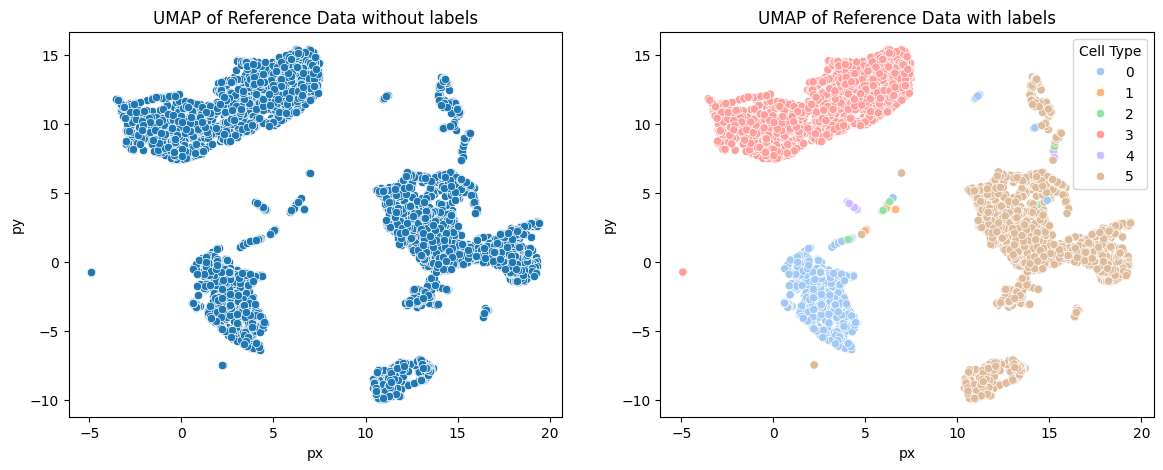

In [16]:
reducer = umap.UMAP(min_dist=0.2, n_components=2, n_epochs=None, n_neighbors=4)
mapper = reducer.fit(embeddings)

plot_df = pd.DataFrame(mapper.embedding_,columns=['px','py'])
labels = geneformer_test_dataset["LVL1"]
plot_df['Cell Type'] = labels


# Create a matplotlib figure and axes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

#plt.style.use("dark_background")

sns.scatterplot(data = plot_df,x='px',y='py',sizes=(50,200),ax=axs[0],palette="pastel")
axs[0].set_title('UMAP of Reference Data without labels')

sns.scatterplot(data = plot_df,x='px',y='py',hue='Cell Type',sizes=(50,200),ax=axs[1],palette="pastel")
axs[1].set_title('UMAP of Reference Data with labels')

### Print the classification report

In [17]:
print(classification_report(cell_types_test,outputs.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       938
           1       1.00      0.26      0.42        19
           2       0.41      0.58      0.48        19
           3       1.00      1.00      1.00      2321
           4       0.94      0.89      0.92        38
           5       0.99      1.00      0.99      3001

    accuracy                           0.99      6336
   macro avg       0.89      0.79      0.80      6336
weighted avg       0.99      0.99      0.99      6336



### Plot the confusion matrix for the test dataset outputs vs true labels

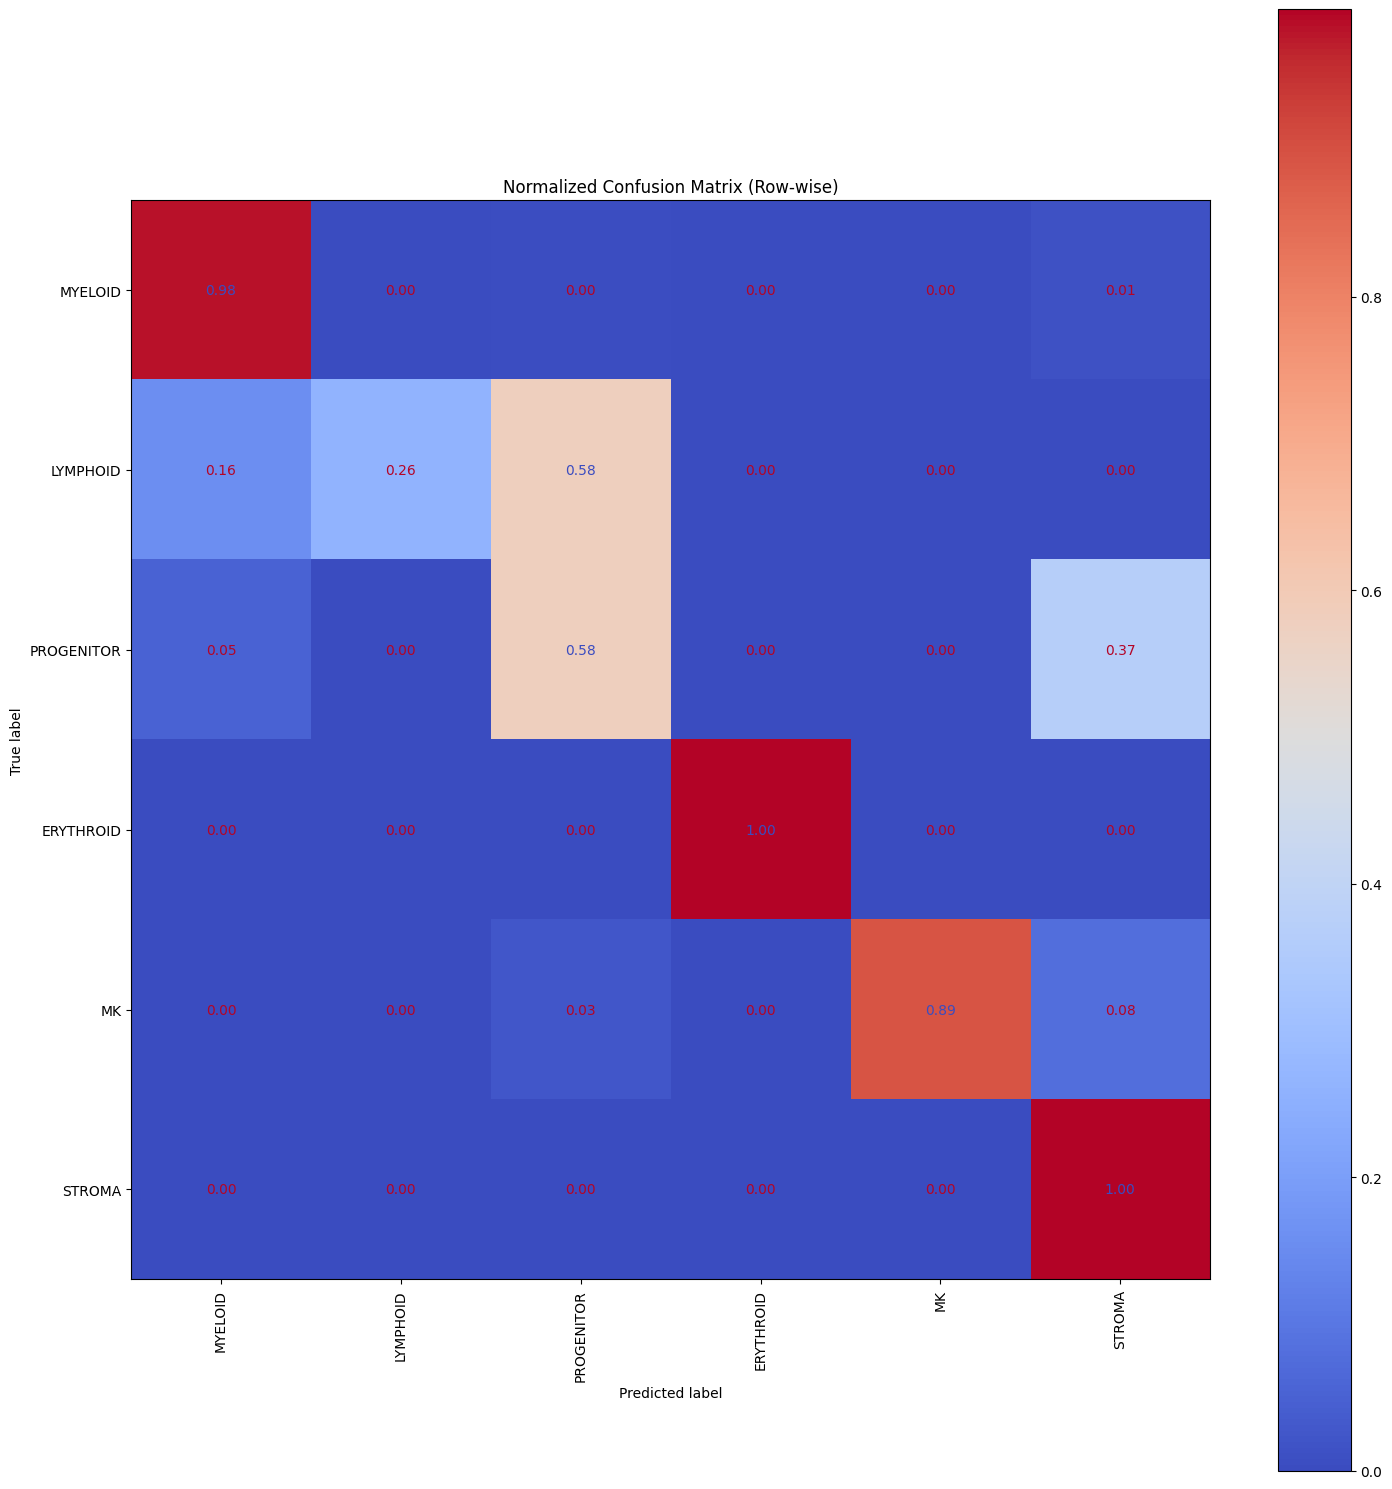

In [18]:
# Compute the confusion matrix
cm = confusion_matrix(cell_types_test, outputs.argmax(axis=1))

# Perform row-wise normalization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Get unique labels in the order they appear in the confusion matrix
unique_labels = np.unique(np.concatenate((cell_types_test, outputs.argmax(axis=1))))

# Use id_class_dict to get the class names
class_names = [id_class_dict[label] for label in unique_labels]

# Create and plot the normalized confusion matrix
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation='vertical', values_format='.2f', cmap='coolwarm')

# Customize the plot
ax.set_title('Normalized Confusion Matrix (Row-wise)')
fig.set_facecolor("none")

plt.tight_layout()
plt.show()

## scGPT Fine-Tuning

Now the same procedure with scGPT
- Loading the fine-tuning model and setting desired configs

In [ ]:
scgpt_config=scGPTConfig(batch_size=10, device=device)
scgpt_fine_tune = scGPTFineTuningModel(scGPT_config=scgpt_config, fine_tuning_head="classification", output_size=len(label_set))

A slightly different methodology for getting the dataset for scGPT since it does not make use of the Hugging Face Dataset class
- Split the data into a train and validation set

In [ ]:
dataset = scgpt_fine_tune.process_data(train_dataset, gene_names = "gene_name")
validation_dataset = scgpt_fine_tune.process_data(test_dataset, gene_names = "gene_name")

For scGPT fine tuning we have to pass in the labels as a separate list
- This is the same for the validation and training sets

In [ ]:
scgpt_fine_tune.train(train_input_data=dataset, train_labels=cell_types_train, validation_input_data=validation_dataset, validation_labels=cell_types_test, epochs=1, optimizer_params={"lr": 2e-5}, lr_scheduler_params={"name":"linear", "num_warmup_steps":0, 'num_training_steps':1})

Fine-Tuning Validation: 100%|██████████| 634/634 [00:39<00:00, 16.18it/s, val_loss=0.0302]


### Get the outputs for the test dataset

In [ ]:
outputs = scgpt_fine_tune.get_outputs(validation_dataset)

Fine-Tuning Validation: 100%|██████████| 634/634 [00:36<00:00, 17.43it/s]


### Get the embeddings for the fine-tuned model

In [ ]:
embeddings = scgpt_fine_tune.get_embeddings(validation_dataset)

Embedding cells: 100%|██████████| 634/634 [00:15<00:00, 39.98it/s]


## We can now get the results of our model and visualise what has been learned

### Visualise the embeddings of the fine-tuned model

Text(0.5, 1.0, 'UMAP of Reference Data with labels')

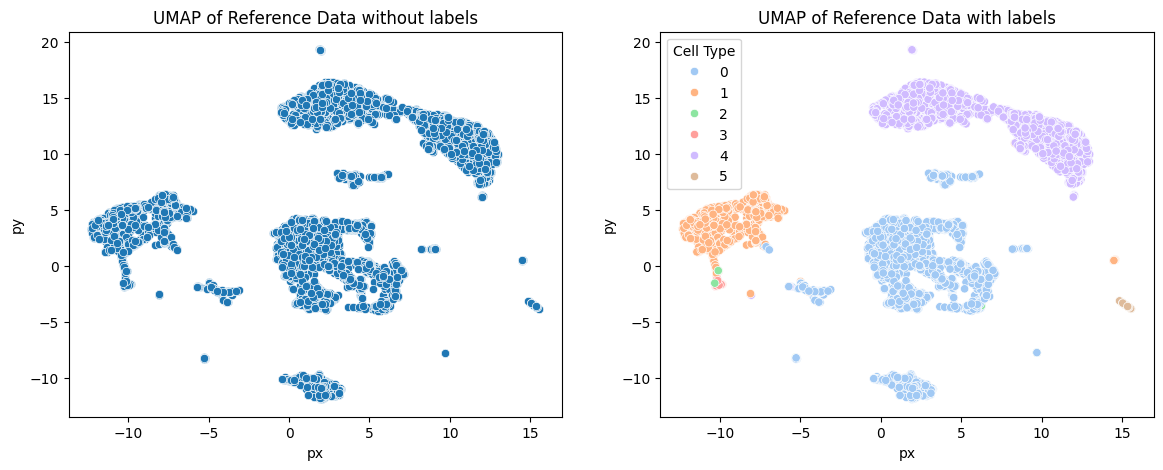

In [ ]:
reducer = umap.UMAP(min_dist=0.2, n_components=2, n_epochs=None, n_neighbors=4)
mapper = reducer.fit(embeddings)

plot_df = pd.DataFrame(mapper.embedding_,columns=['px','py'])
labels = cell_types_test
plot_df['Cell Type'] = labels


# Create a matplotlib figure and axes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

#plt.style.use("dark_background")

sns.scatterplot(data = plot_df,x='px',y='py',sizes=(50,200),ax=axs[0],palette="pastel")
axs[0].set_title('UMAP of Reference Data without labels')

sns.scatterplot(data = plot_df,x='px',y='py',hue='Cell Type',sizes=(50,200),ax=axs[1],palette="pastel")
axs[1].set_title('UMAP of Reference Data with labels')

### Print the classification report

In [ ]:
print(classification_report(cell_types_test,outputs.argmax(axis=1)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3001
           1       0.99      0.98      0.99       938
           2       0.62      0.26      0.37        19
           3       0.64      0.84      0.73        19
           4       1.00      1.00      1.00      2321
           5       0.82      0.97      0.89        38

    accuracy                           0.99      6336
   macro avg       0.85      0.84      0.83      6336
weighted avg       0.99      0.99      0.99      6336



### Plot the confusion matrix of the test outputs vs the true labels

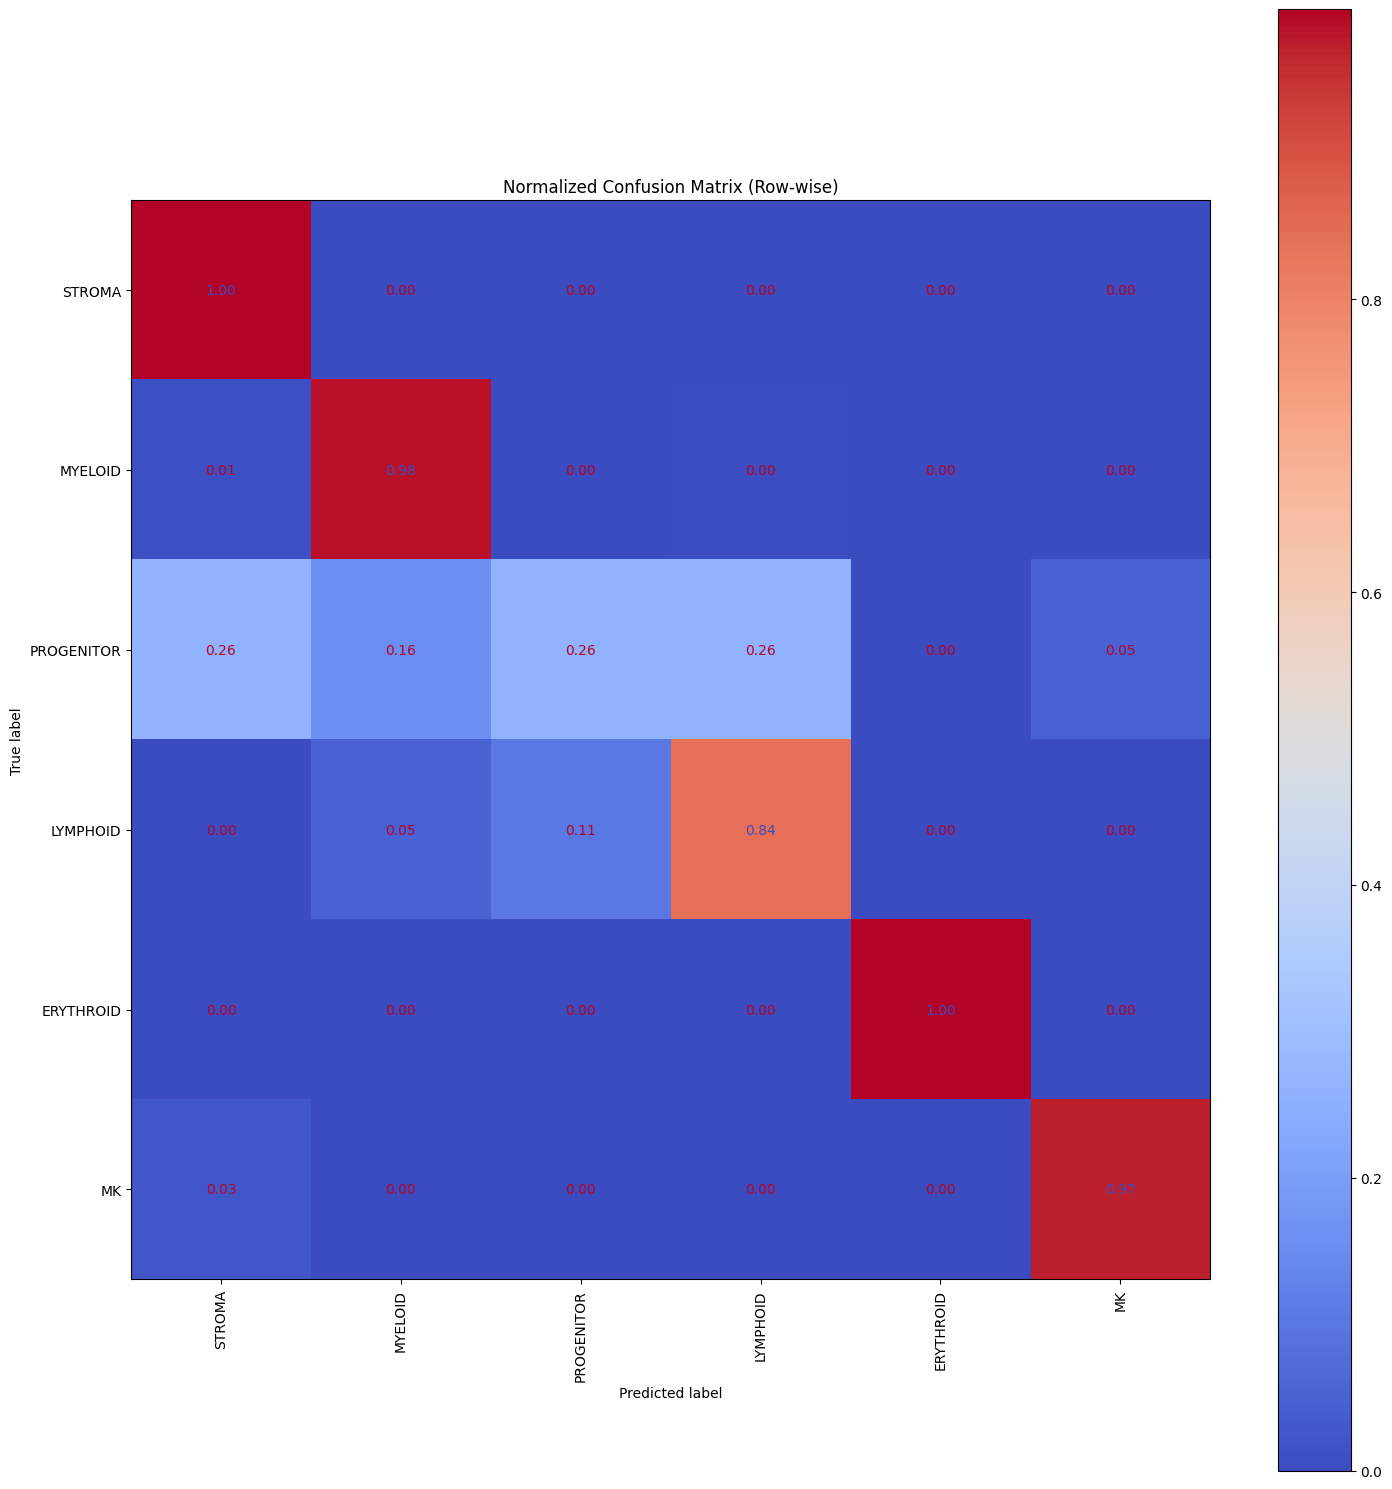

In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(cell_types_test, outputs.argmax(axis=1))

# Perform row-wise normalization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Get unique labels in the order they appear in the confusion matrix
unique_labels = np.unique(np.concatenate((cell_types_test, outputs.argmax(axis=1))))

# Use id_class_dict to get the class names
class_names = [id_class_dict[label] for label in unique_labels]

# Create and plot the normalized confusion matrix
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation='vertical', values_format='.2f', cmap='coolwarm')

# Customize the plot
ax.set_title('Normalized Confusion Matrix (Row-wise)')
fig.set_facecolor("none")

plt.tight_layout()
plt.show()
